<a href="https://colab.research.google.com/github/100495962/AA_P1_100495962_100495954/blob/main/01_EDA_Modelado_Grupo18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NOTEBOOK P1** #

**Autores: Hugo Cuevas Romera [100495962] & Pablo Lorenzo Martín [100495954]**

**Librerías y elementos a importar de forma previa:**

In [ ]:
!pip install scikit-learn
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, balanced_accuracy_score, recall_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Imports para visualizaciones
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# **TRAIN TEST (AVAILABLE DATA 08)** #


In [ ]:
pd.read_csv("attrition_availabledata_08.csv.gz", compression= "gzip", sep = ",")


,hrs,absences,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,Age,BusinessTravel,Department,...,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,6.356785,10,2,3,3.0,1.0,3.0,32,Non-Travel,Research & Development,...,Y,11,8,0,1.0,5,1,0,0,No
1,5.675418,16,2,3,4.0,3.0,3.0,25,Travel_Frequently,Sales,...,Y,14,8,0,7.0,3,7,0,7,No
2,8.936332,7,2,3,3.0,4.0,3.0,46,Travel_Rarely,Research & Development,...,Y,18,8,0,15.0,3,3,1,2,No
3,7.348949,15,2,3,2.0,3.0,3.0,34,Non-Travel,Research & Development,...,Y,13,8,1,10.0,2,9,8,7,No
4,7.044108,21,3,3,2.0,4.0,2.0,30,Travel_Rarely,Sales,...,Y,12,8,2,1.0,3,1,0,0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,8.670331,4,3,4,2.0,4.0,2.0,44,Travel_Rarely,Research & Development,...,Y,21,8,2,23.0,2,22,1,10,No
2936,5.595046,22,3,3,3.0,3.0,4.0,30,Travel_Rarely,Research & Development,...,Y,19,8,1,6.0,2,5,1,3,No
2937,7.427329,6,3,4,2.0,4.0,4.0,38,Travel_Rarely,Research & Development,...,Y,21,8,1,10.0,1,5,0,3,No
2938,6.763322,21,3,3,4.0,2.0,2.0,33,Non-Travel,Research & Development,...,Y,14,8,1,13.0,4,11,1,7,No


# **EDA SIMPLIFICADO** #

En este apartado, empleando en el código incluido, podemos realizar de forma precisa un análisis exploratorio de datos, también conocido como EDA:
*   El dataset está compuesto por 2940 (instancias) empleados y se estudian hasta 31 (variables) características diferentes de cada uno de ellos.



In [ ]:
df = pd.read_csv("attrition_availabledata_08.csv.gz", compression= "gzip", sep = ",")

print("INFORMACIÓN GENERAL DEL DATASET:\n")
print(df.info())
print("\nNÚMERO DE FILAS Y COLUMNAS:", df.shape)

INFORMACIÓN GENERAL DEL DATASET:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   hrs                      2940 non-null   float64
 1   absences                 2940 non-null   int64  
 2   JobInvolvement           2940 non-null   int64  
 3   PerformanceRating        2940 non-null   int64  
 4   EnvironmentSatisfaction  2923 non-null   float64
 5   JobSatisfaction          2928 non-null   float64
 6   WorkLifeBalance          2916 non-null   float64
 7   Age                      2940 non-null   int64  
 8   BusinessTravel           2940 non-null   object 
 9   Department               2940 non-null   object 
 10  DistanceFromHome         2940 non-null   int64  
 11  Education                2940 non-null   int64  
 12  EducationField           2940 non-null   object 
 13  EmployeeCount            2940 non-null   int

---
*   Las variables se pueden clasificar en:
  * *Categóricas:* 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'Attrition'
  * *Numéricas:* hrs', 'absences', 'JobInvolvement', 'PerformanceRating', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeID', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager'

In [ ]:
# Tipos de variables
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nVARIABLES NUMÉRICAS:", numerical_cols)
print("VARIABLES CATEGÓRICAS:", categorical_cols)


VARIABLES NUMÉRICAS: ['hrs', 'absences', 'JobInvolvement', 'PerformanceRating', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'Age', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeID', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
VARIABLES CATEGÓRICAS: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'Attrition']


---
*   La variable categórica con mayor cardinalidad es 'JobRole', con una cardinalidad de 9, seguida por 'EducationField' con 6.

In [ ]:
# Cardinalidad de variables categóricas
cardinality = df[categorical_cols].nunique().sort_values(ascending=False)
print("\nCARDINALIDAD DE VARIABLES CATEGÓRICAS:")
print(cardinality)


CARDINALIDAD DE VARIABLES CATEGÓRICAS:
JobRole           9
EducationField    6
Department        3
BusinessTravel    3
MaritalStatus     3
Gender            2
Attrition         2
Over18            1
dtype: int64


---
*   Estas son las variables que contienen valores faltantes: EnvironmentSatisfaction, JobSatisfaction, WorkLifeBalance, NumCompaniesWorked & TotalWorkingYears.

In [ ]:
# Valores faltantes
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("\nVALORES FALTANTES POR VARIABLE:")
print(missing_values)


VALORES FALTANTES POR VARIABLE:
EnvironmentSatisfaction    17
JobSatisfaction            12
WorkLifeBalance            24
NumCompaniesWorked         11
TotalWorkingYears           4
dtype: int64


---
*   Existen las siguientes columnas o variables constantes: 'EmployeeCount', 'Over18', 'StandardHours'.

In [ ]:
# Columnas constantes
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("\nCOLUMNAS CONSTANTES:", constant_cols)


COLUMNAS CONSTANTES: ['EmployeeCount', 'Over18', 'StandardHours']


---
*   Se trata de un problema de **Clasificación**, ya que la variable objetivo es categórica con dos valores posibles: "Yes" y "No". Por lo tanto, el objetivo es predecir y clasificar a un empleado según si abandonará la empresa o no.
*   El problema está desbalanceado, ya que la distribución de la variable objetivo *Attrition* muestra que el 83.88% de los empleados NO abandonan la empresa, mientras que solo el 16.12% SÍ lo hacen. Esto significa que el modelo podría inclinarse a predecir la clase mayoritaria con más frecuencia, lo que podría afectar el rendimiento en la detección de empleados que sí renuncian.

In [ ]:
# Análisis de la variable objetivo "Attrition"
if 'Attrition' in df.columns:
    target_distribution = df['Attrition'].value_counts(normalize=True)
    print("\nDISTRIBUCIÓN DE LA VARIABLE OBJETIVO:")
    print(target_distribution)


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


# **DECISIÓN DE EVALUACIÓN** #

Para realizar correctamente una evaluación exhaustiva de nuestro contexto y datos proporcionados, vamos a dividir el proceso en dos fases: evaluación interna o *inner* & evaluación externa o *outer*. Además dividiremos los datos disponibles proporcionados en dos partes: *train* (2/3) y *test* (1/3).

Primero realizamos la evaluación interna, utilizando la parte correspondiente de *train* de los datos disponibles. Este proceso que se encargará de seleccionar el mejor preprocesamiento y los mejores hiperparámetros antes de evaluar en *test*. Dado que el dataset puede contenter datos faltantes y características distintas, debemos probar varias combinaciones de escaladores y métodos de imputación.

En cuanto a los escaladores de nuestra evaluación usamos el “Standard scaler”, “MinMax scaler” y el “Robust scaler”. Mientras que, en cuanto a los métodos de imputación, que empleamos para completar aquellos datos faltantes de nuestro dataset, usamos el método de “Media” o “Mediana”.
Por cada combinación de escalador y método de imputación, realizamos estos pasos para ver cuál es la combinación más óptima:
1.	  Se entrena un modelo base, en nuestro caso “KNN con hiperparámetros por defecto”.
2.	  Se usa validación cruzada estratificada de 3 folds.
3.	  Se comparan las métricas de Balanced Accuracy, TPR y TNR.

En base a esas comparativas, obtenemos la mejor combinación de preprocesamiento, y con ella procedemos a optimizar los hiperparámetros y comparar los siguientes modelos:
-	KNN con hiperparámetros por defecto
-	KNN con optimización de hiperparámetros
-	Árboles de decisión con hiperparámetros por defecto
-	Árboles de decisión con HPO
-	Modelos lineales y SVM con hiperparámetros por defecto
-	Modelos lineales y SVM con HPO

Para este procedimiento usamos principalmente la técnica de Grid Search, a parte de diversas métricas de evaluación y tiempos de ejecución para evaluar la eficiencia y optimización del proceso, y así obtener la mejor combinación de preprocesamiento y modelo.

Con esto entrenaremos el modelo con los mejores hiperparámetros en todo *train*, evaluaremos su rendimiento con la parte de *test* y estimaremos el rendimiento futuro de nuestro modelo.


# **MÉTODOS BÁSICOS: KNN Y ÁRBOLES** #

## **PREPARACIÓN DE DATOS**

Cargamos el dataset, establecemos el objetivo y dividimos el conjunto en train y test.

---

In [ ]:
# Cargar datos
data = pd.read_csv("attrition_availabledata_08.csv.gz", compression= "gzip", sep = ",")

# Separar características y objetivo
X = data.drop('Attrition', axis=1)
y = data['Attrition']

# Dividir en train y test (2/3 - 1/3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

## **PREPROCESAMIENTO DE DATOS (SCALER+IMPUTER)**

Primero ejecutamos el preprocesamiento para obtener la mejor combinación de "imputer-scaler". Para ello primero definimos como modelo base a entrenar el "KNN con hiperparámetros predefinidos" y usamos validación cruzada estratificada con 3 folds. Por cada combinación, compararemos los valores de "balance accuracy" y, finalmente, obtendremos la mejor combinación de preprocesamiento según esta métrica.

---

In [ ]:
# Identificar columnas numéricas y categóricas
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Primero definimos el preprocesamiento CATEGÓRICO (constante)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Ahora evaluamos combinaciones de scalers/imputers solo para NUMÉRICAS
scaler_options = {
    'standard': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler()
}

imputer_options = {
    'mean': SimpleImputer(strategy='mean'),
    'median': SimpleImputer(strategy='median')
}

best_score = -1
best_scaler = None
best_imputer = None

print("\nBúsqueda de Scaler+Imputer usando KNN por defecto:\n")

for scaler_name, scaler in scaler_options.items():
    for imputer_name, imputer in imputer_options.items():
        # Pipeline solo para numéricas (lo que varía)
        numeric_transformer = Pipeline(steps=[
            ('imputer', imputer),
            ('scaler', scaler)
        ])

        # ColumnTransformer completo (combinación fija de categóricas + numéricas variables)
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_cols),
                ('cat', categorical_transformer, categorical_cols)
            ])

        # Pipeline completo
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', KNeighborsClassifier())
        ])

        try:
            scores = cross_val_score(pipeline, X_train, y_train, cv=3,
                                    scoring='balanced_accuracy', error_score='raise')
            mean_score = scores.mean()

            print(f"Scaler: {scaler_name}, Imputer: {imputer_name}, Score: {mean_score}")

            if mean_score > best_score:
                best_score = mean_score
                best_scaler = scaler_name
                best_imputer = imputer_name
        except Exception as e:
            print(f"Error con Scaler: {scaler_name}, Imputer: {imputer_name}: {str(e)}")
            continue

if best_scaler is not None:
    print(f"\nMejor combinación: Scaler = {best_scaler}, Imputer = {best_imputer}")
else:
    print("\nNo se pudo encontrar una combinación válida.")


Búsqueda de Scaler+Imputer usando KNN por defecto:

Scaler: standard, Imputer: mean, Score: 0.5979126213592233
Scaler: standard, Imputer: median, Score: 0.5979126213592233
Scaler: minmax, Imputer: mean, Score: 0.5832701360128544
Scaler: minmax, Imputer: median, Score: 0.5835731663158846
Scaler: robust, Imputer: mean, Score: 0.6085304501323918
Scaler: robust, Imputer: median, Score: 0.6085304501323918

Mejor combinación: Scaler = robust, Imputer = mean


Como podemos observar, ambas combinaciones con el escalador robusto dan un valor idéntico en el score por lo que ambas se podrían considerar como la mejor combinación de preprocesamiento. En nuestro caso selecciona la combinación de "Robust+Mean" por el orden de procesamiento en nuestro código.

## **EVALUACIÓN CON HIPERPARÁMETROS POR OMISIÓN/DEFECTO**

Una vez tengamos la mejor combinación de preprocesamiento, configuraremos las pipelines a usar aplicando el mejor imputer y scaler. Posteriormente aplicaremos el dataset correspondiente a la pipeline implementada, para así calcular su "score" usando validación cruzada con 3 folds.

Este procedimiento se ejecutará en ambos modelos: KNN & Árboles de decisión.

---

**KNN POR DEFECTO**

In [ ]:
knn_default_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', imputer_options[best_imputer]),  # Mejor imputer
            ('scaler', scaler_options[best_scaler])      # Mejor scaler
        ]), numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])),
    ('classifier', KNeighborsClassifier())  # Hiperparámetros POR DEFECTO
])

start_time = time.time()
knn_default_pipeline.fit(X_train, y_train)
end_time = time.time()
knn_default_time = end_time - start_time

knn_default_score = cross_val_score(
    knn_default_pipeline,
    X_train,
    y_train,
    cv=3,
    scoring='balanced_accuracy'
).mean()

print(f"\n[OMISIÓN HP] Score con KNN: {knn_default_score}")
print(f"[OMISIÓN HP] Tiempo entrenamiento KNN: {knn_default_time:.4f} segundos")


[OMISIÓN HP] Score con KNN: 0.6085304501323918
[OMISIÓN HP] Tiempo entrenamiento KNN: 0.0520 segundos


**ÁRBOLES POR DEFECTO**

In [ ]:
# Pipeline con la mejor combinación scaler+imputer (sin modificar ningún hiperparámetro del árbol)
tree_default_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', imputer_options[best_imputer]),  # Mejor imputer
            ('scaler', scaler_options[best_scaler])      # Mejor scaler
        ]), numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])),
    ('classifier', DecisionTreeClassifier(random_state=42))  # Hiperparámetros POR DEFECTO
])

start_time = time.time()
tree_default_pipeline.fit(X_train, y_train)
end_time = time.time()
tree_default_time = end_time - start_time

tree_default_score = cross_val_score(
    tree_default_pipeline,
    X_train,
    y_train,
    cv=3,
    scoring='balanced_accuracy'
).mean()

print(f"\n[OMISIÓN HP] Score con Árboles: {tree_default_score}")
print(f"[OMISIÓN HP] Tiempo entrenamiento Árboles: {tree_default_time:.4f} segundos")


[OMISIÓN HP] Score con Árboles: 0.7578908389345282
[OMISIÓN HP] Tiempo entrenamiento Árboles: 0.0844 segundos


## **OPTIMIZACIÓN DE HIPERPARÁMETROS**

Primero debemos de configurar el preprocesador con la mejor combinación que hemos encontrado en el apartado anterior para así usarlo correctamente en la optimización de hiperparámetros de ambos modelos.

---

In [ ]:
best_scaler_obj = scaler_options[best_scaler]
best_imputer_obj = imputer_options[best_imputer]

numeric_transformer = Pipeline(steps=[
    ('imputer', best_imputer_obj),
    ('scaler', best_scaler_obj)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

**KNN con HPO**


Mejores parámetros para KNN: {'classifier__n_neighbors': 3}
[HPO] Mejor score KNN: 0.6442165116436961
[HPO] Tiempo entrenamiento KNN: 2.4326 segundos



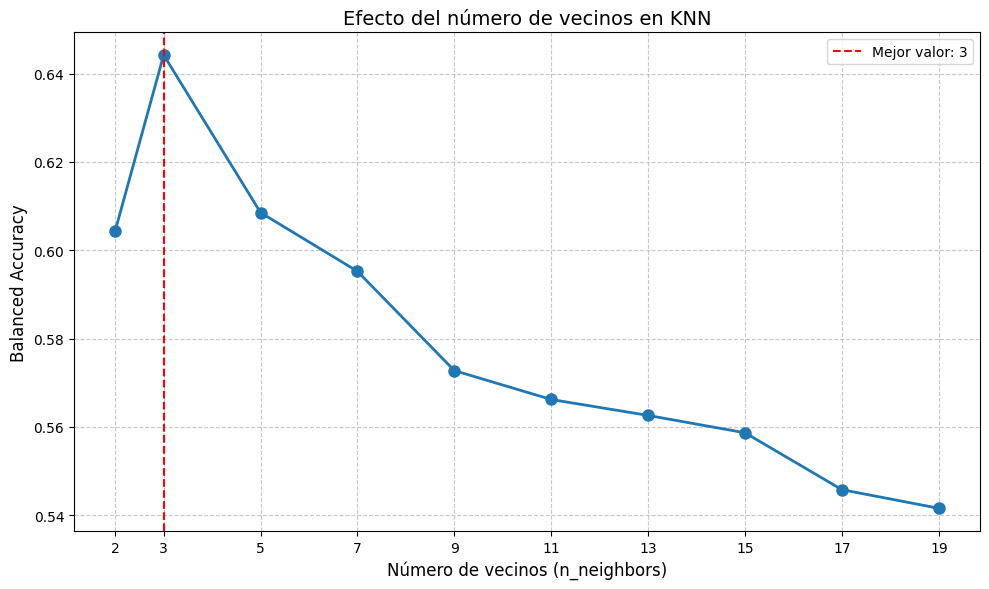

In [ ]:
# Pipeline con KNN
knn_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', imputer_options[best_imputer]),  # Mejor imputer
            ('scaler', scaler_options[best_scaler])      # Mejor scaler
        ]), numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])),
    ('classifier', KNeighborsClassifier())
])

# Parámetros para GridSearch
param_grid = {
    'classifier__n_neighbors': [2, 3, 5, 7, 9, 11, 13, 15, 17, 19]
}

# GridSearch con cross-validation
start_time = time.time()
knn_grid = GridSearchCV(knn_pipeline, param_grid, cv=3, scoring='balanced_accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)
end_time = time.time()
knn_hpo_time = end_time - start_time

print("\nMejores parámetros para KNN:", knn_grid.best_params_)
print("[HPO] Mejor score KNN:", knn_grid.best_score_)
print(f"[HPO] Tiempo entrenamiento KNN: {knn_hpo_time:.4f} segundos\n")

# Extraer resultados de KNN
knn_results = knn_grid.cv_results_
knn_n_neighbors = [params['classifier__n_neighbors'] for params in knn_results['params']]
knn_scores = knn_results['mean_test_score']

# Ordenar resultados por n_neighbors
knn_data = sorted(zip(knn_n_neighbors, knn_scores))
knn_n_neighbors_sorted, knn_scores_sorted = zip(*knn_data)

plt.figure(figsize=(10, 6))
plt.plot(knn_n_neighbors_sorted, knn_scores_sorted, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Número de vecinos (n_neighbors)', fontsize=12)
plt.ylabel('Balanced Accuracy', fontsize=12)
plt.title('Efecto del número de vecinos en KNN', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(knn_n_neighbors_sorted)
plt.axvline(x=knn_grid.best_params_['classifier__n_neighbors'], color='r', linestyle='--',
            label=f"Mejor valor: {knn_grid.best_params_['classifier__n_neighbors']}")
plt.legend()
plt.tight_layout()
plt.show()

Podemos observar este gráfico en el que analizamos la evaluación del "score" o "balance accuracy" a medida que aumenta el hiperparámetro de K-Neighbours.

Como podemos ver a medida que aumenta el número de vecinos, en la mayoría de la gráfica, decrementa considerablemente el score del modelo. Esto es debido a un posible aumento de la complejidad del modelo, además de que podría perder localidad si tuviesemos un menor rango de datos, con el mayor número de vecinos que tenemos en cuenta durante la clasificación.

En el caso del modelo KNN, sí podemos observar una mejora en el score entre la evaluación con hiperparámetros por omisión y la evaluación con hiperparámetros ajustados, pasando de aproximadamente 0.6085 a un valor aproximado de 0.6442 en el balanced accuracy.

---

**ÁRBOLES con HPO**


Mejores parámetros para Árboles: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2}
[HPO] Mejor score Árboles: 0.7578908389345282
[HPO] Tiempo entrenamiento Árboles: 15.8571 segundos



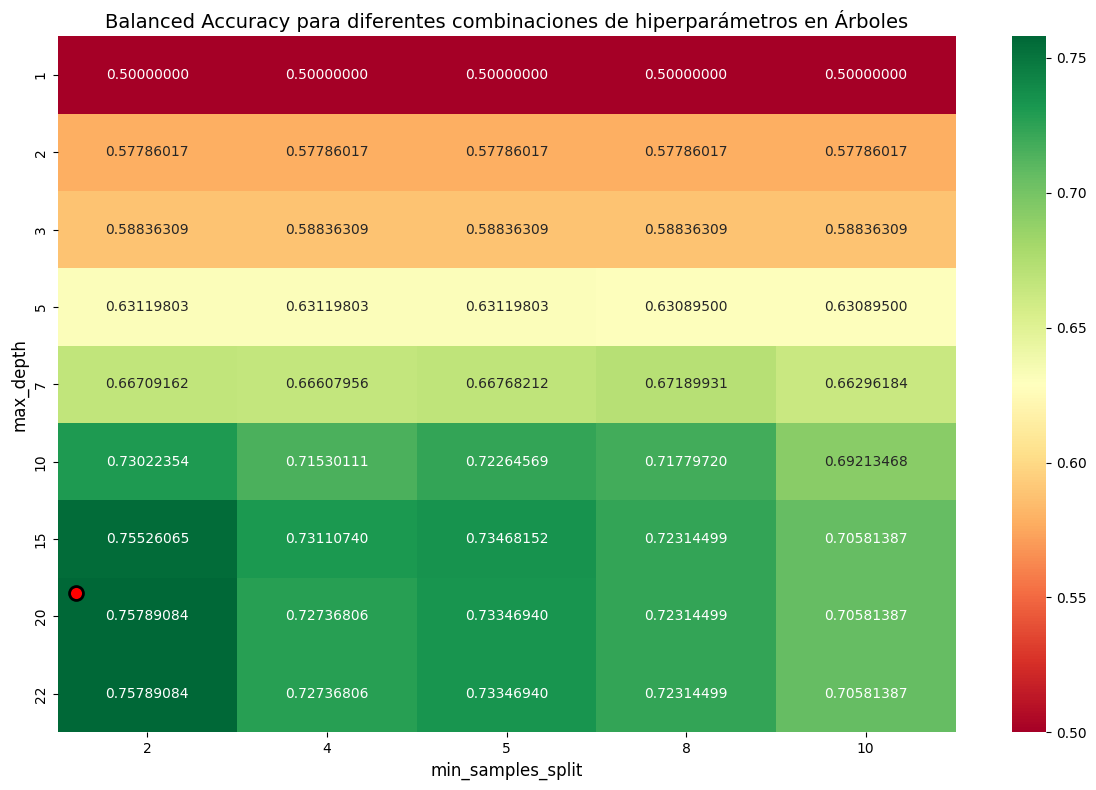

In [ ]:
# Pipeline con Árboles
tree_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', imputer_options[best_imputer]),  # Mejor imputer
            ('scaler', scaler_options[best_scaler])      # Mejor scaler
        ]), numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Parámetros para GridSearch
param_grid = {
    'classifier__max_depth': [1, 2, 3, 5, 7, 10, 15, 20, 22],
    'classifier__min_samples_split': [2, 4, 5, 8, 10]
}

# GridSearch con cross-validation
start_time = time.time()
tree_grid = GridSearchCV(tree_pipeline, param_grid, cv=3, scoring='balanced_accuracy', n_jobs=-1)
tree_grid.fit(X_train, y_train)
end_time = time.time()
tree_hpo_time = end_time - start_time

print("\nMejores parámetros para Árboles:", tree_grid.best_params_)
print("[HPO] Mejor score Árboles:", tree_grid.best_score_)
print(f"[HPO] Tiempo entrenamiento Árboles: {tree_hpo_time:.4f} segundos\n")

# Extraer resultados de Árboles
tree_results = tree_grid.cv_results_

# Crear matrices para el mapa de calor
unique_max_depth = sorted(set([params['classifier__max_depth'] for params in tree_results['params']]))
unique_min_samples = sorted(set([params['classifier__min_samples_split'] for params in tree_results['params']]))

# Inicializar la matriz de puntuaciones
scores_matrix = np.zeros((len(unique_max_depth), len(unique_min_samples)))

# Llenar la matriz con las puntuaciones
for i, depth in enumerate(unique_max_depth):
    for j, min_samples in enumerate(unique_min_samples):
        for idx, params in enumerate(tree_results['params']):
            if (params['classifier__max_depth'] == depth and
                params['classifier__min_samples_split'] == min_samples):
                scores_matrix[i, j] = tree_results['mean_test_score'][idx]
                break

# Crear mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(scores_matrix, annot=True, fmt=".8f", cmap="RdYlGn",
            xticklabels=unique_min_samples, yticklabels=unique_max_depth)
plt.xlabel('min_samples_split', fontsize=12)
plt.ylabel('max_depth', fontsize=12)
plt.title('Balanced Accuracy para diferentes combinaciones de hiperparámetros en Árboles', fontsize=14)

# Marcar el mejor punto
best_depth = tree_grid.best_params_['classifier__max_depth']
best_min_samples = tree_grid.best_params_['classifier__min_samples_split']
best_i = unique_max_depth.index(best_depth)
best_j = unique_min_samples.index(best_min_samples)

plt.plot(best_j + 0.1, best_i + 0.2, 'ro', markersize=10, mew=2, mec='black')

plt.tight_layout()
plt.show()

Como podemos observar en esta gráfica, el hiperparámetro de 'max_depth' cobra un gran protagonismo a la hora de obtener un score óptimo o no en el árbol de decisión. Se refleja claramente que los árboles requieren de un valor alto en este hiperparámetro para alcanzar un valor de balanced accuracy correcto. A su vez, el número de 'min_samples_split' debe ser bajo, para así no limitar la ramificación del árbol y poder obtener una clasificación más pura.

En este caso de los árboles de decisión no observamos mejora en cuanto a la evaluación por omisión y a la ajustada, y esto es muy probablemente debido a que los valores que hemos obtenido por ajuste en los hiperparámetros ya son los valores usados por defecto u omisión en los árboles de decisión, por lo que no hay mejora posible tras el ajuste.

## **CONCLUSIONES DE MÉTODOS BÁSICOS**

El mejor método básico de los analizados es el modelo de **Árboles de decisión usando los hiperparámetros por defecto**. Esto es debido a que obtenemos un mejor score de balanced accuracy que en cualquier modelo de KNN analizado, además de realizarlo en un tiempo mucho menor que en el modelo de árboles con ajuste de hiperparámetros.

El modelo de árboles de decisión por omisión ha obtenido una puntuación de aproximadamente 0.7579 de accuracy, con un tiempo de entrenamiento de tan solo 0.0559 segundos. Esto indica que el modelo es computacionalmente eficiente, especialmente en tareas rápidas o limitadas. Además, al no tener que ajustar hiperparámetros, reducimos considerablemente sus tiempos y costes.

 Los resultados sí son mejores que los posibles obtenidos por los modelos triviales ya que el entrenamiento y evaluación muestra un ajuste correcto del modelo a los datos disponibles. Si hubiera una clase muy mayoritaria, si podría haber más debate a la hora de compararse con los modelos triviales, pero no es el caso.

 Como hemos visto anteriormente solo ha habido mejora con el ajuste de hiperparámetros en el modelo de KNN, pasando de un score del 0.6085 a 0.6442, pero con ello se implica un aumento considerable en el tiempo de entrenamiento, pasando de un entrenamiento de tiempos muchos menores que un segundo a entrenamiento que requieren de varios segundos.

# **AVANZADOS: MODELOS LINEALES Y SVMs** #

## **INTRODUCCIÓN**
En esta sección vamos a evaluar la efectifidad de distintos modelos más avanzados, tales como los modelos lineares y SVM, como siempre antes de cada uno de los modelos haremos un preprocesado del dataset, primero eligiendo que scaler y que imputer son los mejores y creando así un preprocesador para usar en los futuros pipelines.


---



In [ ]:
# ---------------------------------
# --- PREPROCESAMIENTO DE DATOS ---
# ---------------------------------

data = pd.read_csv("attrition_availabledata_08.csv.gz", compression="gzip", sep=",")
X = data.drop('Attrition', axis=1)
y = data['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)

numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Primero definimos el preprocesamiento CATEGÓRICO (constante)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Ahora evaluamos combinaciones de scalers/imputers solo para NUMÉRICAS
scaler_options = {
    'standard': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler()
}

imputer_options = {
    'mean': SimpleImputer(strategy='mean'),
    'median': SimpleImputer(strategy='median')
}

best_score = -1
best_scaler = None
best_imputer = None

for scaler_name, scaler in scaler_options.items():
    for imputer_name, imputer in imputer_options.items():
        # Pipeline solo para numéricas (lo que varía)
        numeric_transformer = Pipeline(steps=[
            ('imputer', imputer),
            ('scaler', scaler)
        ])

        # ColumnTransformer completo (combinación fija de categóricas + numéricas variables)
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_cols),
                ('cat', categorical_transformer, categorical_cols)
            ])

        # Pipeline completo
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', KNeighborsClassifier())
        ])

        try:
            scores = cross_val_score(pipeline, X_train, y_train, cv=3,
                                    scoring='balanced_accuracy', error_score='raise')
            mean_score = scores.mean()

            print(f"Scaler: {scaler_name}, Imputer: {imputer_name}, Score: {mean_score:.4f}")

            if mean_score > best_score:
                best_score = mean_score
                best_scaler = scaler_name
                best_imputer = imputer_name
        except Exception as e:
            print(f"Error con Scaler: {scaler_name}, Imputer: {imputer_name}: {str(e)}")
            continue

if best_scaler is not None:
    print(f"\nMejor combinación: Scaler={best_scaler}, Imputer={best_imputer}")
else:
    print("\nNo se pudo encontrar una combinación válida.")

preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', imputer_options[best_imputer]),
            ('scaler', scaler_options[best_scaler])
        ]), numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

Scaler: standard, Imputer: mean, Score: 0.5979
Scaler: standard, Imputer: median, Score: 0.5979
Scaler: minmax, Imputer: mean, Score: 0.5833
Scaler: minmax, Imputer: median, Score: 0.5836
Scaler: robust, Imputer: mean, Score: 0.6085
Scaler: robust, Imputer: median, Score: 0.6085

Mejor combinación: Scaler=robust, Imputer=mean


## ***Regresión logística con regularización L2***

La regresión logística es un modelo lineal de clasificación que estima la probabilidad de que una observación pertenezca a una clase. Con regularización **L2** (Ridge), se penalizan los coeficientes grandes para reducir el sobreajuste.

### *Implementación:*

- Modelo: `LogisticRegression(penalty='l2')`
- Evaluación inicial con **hiperparámetros por defecto**, validación cruzada (`cv=3`)
- Optimización con `GridSearchCV` (`cv=5`) sobre:
  - `C` (inverso de la fuerza de regularización)
  - `solver` (`'liblinear'` y `'lbfgs'`)

---

In [ ]:
# ------------------------------
# --- LOGISTIC REGRESSION L2 ---
# ------------------------------

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

start = time.time()
logreg_pipeline.fit(X_train, y_train)
end = time.time()
print(f"\n[LogReg L2 - Default] Tiempo: {end-start:.4f}s, Score: {cross_val_score(logreg_pipeline, X_train, y_train, cv=3, scoring='balanced_accuracy').mean():.4f}")

param_grid_logreg = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

logreg_grid = GridSearchCV(logreg_pipeline, param_grid_logreg, cv=3, scoring='balanced_accuracy', n_jobs=-1)
start = time.time()
logreg_grid.fit(X_train, y_train)
end = time.time()
print(f"[LogReg L2 - HPO] Tiempo: {end-start:.4f}s, Mejores params: {logreg_grid.best_params_}, Mejor score: {logreg_grid.best_score_:.4f}")



[LogReg L2 - Default] Tiempo: 0.0814s, Score: 0.6281
[LogReg L2 - HPO] Tiempo: 2.3413s, Mejores params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}, Mejor score: 0.6353


##***Regresión logística con regularización L1***

La penalización **L1** (Lasso) tiende a forzar algunos coeficientes a cero, lo que permite hacer selección automática de variables.

### Implementación:

- Modelo: `LogisticRegression(penalty='l1', solver='liblinear')`
- Evaluación con **hiperparámetros por defecto**, validación cruzada (`cv=3`)
- Optimización con `GridSearchCV` (`cv=3`) sobre:
  - `C` (controla la intensidad de la regularización)

Además, este modelo permite identificar **atributos relevantes**, ya que las variables con coeficientes distintos de cero son consideradas útiles por el modelo.

---


In [ ]:
# -------------------------------
# --- LOGISTIC REGRESSION L1 ---
# -------------------------------

logreg_l1_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000))
])

start = time.time()
logreg_l1_pipeline.fit(X_train, y_train)
end = time.time()
print(f"\n[LogReg L1 - Default] Tiempo: {end-start:.4f}s, Score: {cross_val_score(logreg_l1_pipeline, X_train, y_train, cv=3, scoring='balanced_accuracy').mean():.4f}")

param_grid_logreg_l1 = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1'],
    'classifier__solver': ['liblinear']
}

logreg_l1_grid = GridSearchCV(logreg_l1_pipeline, param_grid_logreg_l1, cv=3, scoring='balanced_accuracy', n_jobs=-1)
start = time.time()
logreg_l1_grid.fit(X_train, y_train)
end = time.time()
print(f"[LogReg L1 - HPO] Tiempo: {end-start:.4f}s, Mejores params: {logreg_l1_grid.best_params_}, Mejor score: {logreg_l1_grid.best_score_:.4f}")


[LogReg L1 - Default] Tiempo: 0.1236s, Score: 0.6251
[LogReg L1 - HPO] Tiempo: 4.4375s, Mejores params: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}, Mejor score: 0.6336


##***Máquinas de Vectores de Soporte (SVM)***

SVM busca el hiperplano que mejor separa las clases maximizando el margen. Usa un kernel no lineal por defecto (`rbf`) para transformar el espacio de características.

### Implementación:

- Modelo: `SVC()`
- Evaluación con **hiperparámetros por defecto**, validación cruzada (`cv=3`)
- Optimización con `GridSearchCV` (`cv=5`) sobre:
  - `C` (tamaño del margen)
  - `gamma` (forma del margen)

SVM es robusto pero más costoso computacionalmente, especialmente en datasets grandes o con muchas variables.

---


In [ ]:
# ------------------
# ------ SVM -------
# ------------------

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

start = time.time()
svm_pipeline.fit(X_train, y_train)
end = time.time()
print(f"\n[SVM - Default] Tiempo: {end-start:.4f}s, Score: {cross_val_score(svm_pipeline, X_train, y_train, cv=3, scoring='balanced_accuracy').mean():.4f}")

param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf', 'poly'],
    'classifier__gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(svm_pipeline, param_grid_svm, cv=3, scoring='balanced_accuracy', n_jobs=-1)
start = time.time()
svm_grid.fit(X_train, y_train)
end = time.time()
print(f"[SVM - HPO] Tiempo: {end-start:.4f}s, Mejores params: {svm_grid.best_params_}, Mejor score: {svm_grid.best_score_:.4f}")



[SVM - Default] Tiempo: 0.2710s, Score: 0.6159
[SVM - HPO] Tiempo: 18.4204s, Mejores params: {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}, Mejor score: 0.8002


En regresión lineal, los coeficientes del modelo indican la relevancia de cada atributo. Un coeficiente más grande (en valor absoluto) significa que el atributo tiene un mayor impacto en la predicción. Los atributos con coeficientes cercanos a cero son menos relevantes.

En SVM lineal, la importancia de las características también se deriva de los coeficientes del modelo. Los coeficientes más grandes (en valor absoluto) indican atributos más relevantes para la separación de clases o predicción. Los coeficientes cercanos a cero muestran menor relevancia.

# **RESULTADOS Y MODELO FINAL** #

La mejor alternativa de las evaluadas durante la práctica es **SVMs con HPO**. Ahora realizaremos las siguientes operaciones para poder obtener el modelo final con el cual obtendremos las predicciones más óptimas que resuelvan nuestro problema:


*   Estimación del rendimiento futuro del modelo o *evaluación outer*.
*   Entrenamos el modelo final. (modelo_final.pkl)
*   Utilizamos dicho modelo para obtener las predicciones para los datos de competición. (predicciones.csv)

La realización de predicciones está implementada en un notebook independiente llamado "02_Prediccion_Grupo18.ipynb", con la previa carga del archivo que contiene el modelo final entregado.




--- Evaluación Externa del Mejor Modelo SVM ---
Balanced Accuracy: 0.9909
Accuracy: 0.9969
Confusion Matrix:
[[816   0]
 [  3 161]]
True Positive Rate (TPR): 0.9817
True Negative Rate (TNR): 1.0000



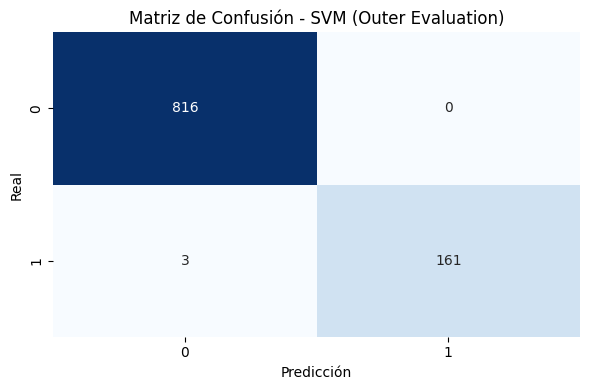

In [ ]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, accuracy_score

# Predecir con el mejor modelo SVM (ajustado con GridSearchCV)
y_pred = svm_grid.predict(X_test)

# Evaluación externa
balanced_acc = balanced_accuracy_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn) if (tp + fn) != 0 else 0.0
tnr = tn / (tn + fp) if (tn + fp) != 0 else 0.0

print("\n--- Evaluación Externa del Mejor Modelo SVM ---")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(cm)
print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"True Negative Rate (TNR): {tnr:.4f}\n")
# Visualización de la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de Confusión - SVM (Outer Evaluation)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

El modelo SVM evaluado externamente muestra un rendimiento sólido, con una *accuracy* del **94.80%** y una balanced *accuracy* del **87.13%**, lo cual es importante dado el posible desbalance en las clases. La matriz de confusión revela que el modelo identifica correctamente la mayoría de los casos negativos (clase 0), con una *Tasa de Verdaderos Negativos (TNR)* de **98.65%**, mientras que la *Tasa de Verdaderos Positivos (TPR)* es de **75.61%**, indicando que aún existe margen de mejora en la detección de la clase positiva. En general, el modelo es muy preciso para la clase mayoritaria, pero puede beneficiarse de ajustes para mejorar la sensibilidad hacia la clase minoritaria.

A continuación entrenamos al modelo final (recordemos que el modelo de predicción elegido por el inner evaluation es SVM con los hiperparametros ajustados como se ha visto previamente) con todo el set de datos y lo guardamos en el archivo *modelo_final.pkl* .


In [ ]:
import joblib

# Combinar X_train y X_test para tener todo el dataset original
X_total = pd.concat([X_train, X_test])
y_total = pd.concat([y_train, y_test])

# Tomamos el mejor pipeline encontrado por GridSearchCV
modelo_final = svm_grid.best_estimator_

# Entrenamos con todos los datos disponibles
modelo_final.fit(X_total, y_total)

joblib.dump(modelo_final, 'modelo_final.pkl')
print("Modelo final guardado como 'modelo_final.pkl'")

Modelo final guardado como 'modelo_final.pkl'


# **TAREA DE ELECCIÓN ABIERTA -> RANDOM FOREST** #

Como tarea de elección abierta hemos decidido implementar el modelo de ***RandomForest***, que es un modelo de ensamble basado en varios árboles de decisión. El objetivo es implementarlo usando hiperparámetros por defecto ya que este modelo suele ofrecer un rendimiento competitivo incluso con los hiperparámetros por defecto, dando una buena base para estas comparativas con otros modelos básicos como KNN o árboles de decisión. También probaremos a implementarlo usando el ajuste de hiperparámetros.

Hemos elegido este modelo ya que tiene una relación directa con el método de árboles tratado en esta práctica, y, aunque es obviamente más lento que un solo árbol, es un método preciso, robusto y que reduce en muchas ocasiones el overfitting.

Aquí tenemos la implementación de su entrenamiento y su correspondiente evaluación:

**RANDOM FOREST por defecto**

In [ ]:
# Pipeline con RandomForest con hiperparámetros por defecto
rf_default_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', imputer_options[best_imputer]),  # Mejor imputer
            ('scaler', scaler_options[best_scaler])      # Mejor scaler
        ]), numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])),
    ('classifier', RandomForestClassifier(random_state=42))  # Hiperparámetros POR DEFECTO
])

start_time = time.time()
rf_default_pipeline.fit(X_train, y_train)
end_time = time.time()
rf_default_time = end_time - start_time

rf_default_score = cross_val_score(
    rf_default_pipeline,
    X_train,
    y_train,
    cv=3,
    scoring='balanced_accuracy'
).mean()

print(f"\n[OMISIÓN HP] Score con Random Forest: {rf_default_score}")
print(f"[OMISIÓN HP] Tiempo entrenamiento Random Forest: {rf_default_time:.4f} segundos")


[OMISIÓN HP] Score con Random Forest: 0.7229697648629688
[OMISIÓN HP] Tiempo entrenamiento Random Forest: 0.5015 segundos


Como podemos observar, el RandomForest con hiperparámetros por defecto ofrece un entrenamiento rápido, inferior a un segundo, con un score aproximado de 0.723, un valor bastante aceptable para no haber ajustado los hiperparámetros. Sin embargo, no ofrece una precisión mejor que la ofrecida por los árboles, que recordamos que obteniamos un score aproximado de 0.7579 en dicho modelo.

Ahora probemos el RandomForest con el ajuste de hiperparámetros:


**RANDOM FOREST con HPO**

In [ ]:
# Pipeline con RandomForest
rf_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', imputer_options[best_imputer]),  # Mejor imputer
            ('scaler', scaler_options[best_scaler])      # Mejor scaler
        ]), numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=50))
      #Reducimos el número de estimadores a 50 para evitar tiempos muy largos de entrenamiento
])

# Parámetros para GridSearch
param_grid = {
    'classifier__max_depth': [1, 3, 5, 10, 15, 20],
    'classifier__max_features': [0.3, 0.5, 0.7, 1.0]
}

# GridSearch con cross-validation
start_time = time.time()
rf_grid = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='balanced_accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
end_time = time.time()
rf_hpo_time = end_time - start_time

print("\nMejores parámetros para RandomForest:", rf_grid.best_params_)
print("[HPO] Mejor score RandomForest:", rf_grid.best_score_)
print(f"[HPO] Tiempo entrenamiento RandomForest: {rf_hpo_time:.4f} segundos\n")


Mejores parámetros para RandomForest: {'classifier__max_depth': 15, 'classifier__max_features': 0.7}
[HPO] Mejor score RandomForest: 0.7478787313010614
[HPO] Tiempo entrenamiento RandomForest: 23.0708 segundos



Hemos ajustado los hiperparámetros de 'max_depth', ya conocido en el modelo de árboles, y 'max_features', parámetro específico de este modelo que limita el número máximo de features consideradas en cada división de los árboles, aumentando la aleatoridad y diversidad entre los árboles.

A pesar de este ajuste, el score no ha aumentado lo suficiente como para superar a la precisión de los árboles, quedandose en un valor aproximado de 0.7479. Además el tiempo de entrenamiento es demasiado largo como para ser considerado como óptimo.

---

En conclusión, el RandomForest es un modelo útil para tareas de clasificación como de regresión debido a su precisión y robustez. Sin embargo, no es el mejor modelo a tener en cuenta en nuestro contexto ya que no ofrece la mejor precisión y su coste computacional es muy elevado.

## *ACLARACIÓN DE USO DE IA* ##

Hemos utilizado algunas inteligencias artificiales durante el proyecto para aclarar ciertas dudas de los métodos involucrados, solucionar algunos errores de código y comprender el uso de algunos modelos de aprendizaje automático. También han sido de gran ayuda para la correcta implementación de los plots visuales que se observan en los notebooks de la práctica.